# Task 2 — Vanilla GAN on MNIST with Logistic Loss

Same architecture as Task 1 but with logistic (softplus) loss instead of BCE.
We compare generated samples at epochs 5, 10, and 50 against Task 1.

## Loss function

Following [Brandon Amos's blog](https://bamos.github.io/2016/08/09/deep-completion/), we replace the original `sigmoid + BCELoss` with `sigmoid_cross_entropy_with_logits` (TF) — PyTorch's equivalent is `BCEWithLogitsLoss` applied to raw Discriminator logits.

Substituting $\sigma(f) = \frac{1}{1+e^{-f}}$ into the binary cross-entropy formula:

$$\ell(f, y) = -\bigl[y \log \sigma(f) + (1-y) \log(1 - \sigma(f))\bigr]$$

- $y=1$: $-\log \sigma(f) = \log(1 + e^{-f}) = \texttt{softplus}(-f)$
- $y=0$: $-\log(1-\sigma(f)) = \log(1 + e^{f}) = \texttt{softplus}(f)$

The Discriminator and Generator losses are therefore:

- **Discriminator**: `softplus(-f_real).mean() + softplus(f_fake).mean()`
- **Generator**: `softplus(-f_fake).mean()`

The Discriminator outputs raw logits (no final sigmoid), and the loss is computed internally in `GAN.py` via `F.softplus`. See Task 1 for why `BCEWithLogitsLoss` was chosen over the original `sigmoid + BCELoss`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import global_config as gc
from utils import device_check, show_generated_images
from GAN import Generator, Discriminator, train_GAN

## General setup

In [2]:
LOG_WANDB = True
SEED = 1

# Device setup
device = device_check()

# Reproducibility
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
    PIN_MEMORY = True
    NUM_WORKERS = 8
    PERSISTENT_WORKERS = True
    PREFETCH_FACTOR = 4
else:
    PIN_MEMORY = False
    NUM_WORKERS = 0
    PERSISTENT_WORKERS = False
    PREFETCH_FACTOR = 2

PyTorch: 2.11.0+cu130 | Python: 3.11.15 | OS: Linux 5.15.0-168-generic
CUDA available: True
GPUs: 1 x NVIDIA GeForce RTX 2080 Ti (11.3 GB)
CUDA: 13.0 | cuDNN: 91900
Using cuda / NVIDIA GeForce RTX 2080 Ti


## Load MNIST dataset

In [3]:
BATCH_SIZE = 256

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root=gc.DATA_DIR,
    train=True,
    transform=transform,
    download=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
    prefetch_factor=PREFETCH_FACTOR,
)

print("Number of training samples:", len(train_dataset))
print("Number of batches per epoch:", len(train_loader))

Number of training samples: 60000
Number of batches per epoch: 234


## Visualize a few real images

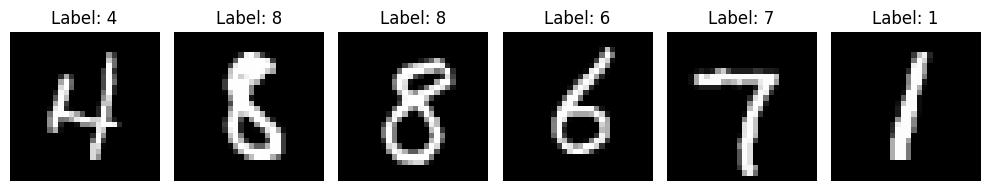

In [4]:
real_images, real_labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for i in range(6):
    axes[i].imshow(real_images[i].squeeze(), cmap="gray")
    axes[i].set_title(f"Label: {real_labels[i].item()}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Initialize models

In [5]:
LATENT_DIM = 100
G_HIDDEN_DIM = 128
D_HIDDEN_DIM = 128
IMAGE_DIM = 28 * 28

G = Generator(
    z_dim=LATENT_DIM,
    h_dim=G_HIDDEN_DIM,
    x_dim=IMAGE_DIM,
).to(device)

D = Discriminator(
    x_dim=IMAGE_DIM,
    h_dim=D_HIDDEN_DIM,
).to(device)

print(G)
print()
print(D)

Generator(
  (fc1): Linear(in_features=100, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=784, bias=True)
)

Discriminator(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)


## Define optimizers

No criterion object is needed — logistic loss is computed inside `train_GAN` via `F.softplus`.

In [6]:
LR = 1e-3
BETAS = (0.9, 0.999)

g_optimizer = optim.Adam(G.parameters(), lr=LR, betas=BETAS)
d_optimizer = optim.Adam(D.parameters(), lr=LR, betas=BETAS)

## Train the GAN with logistic loss

In [7]:
EPOCHS = 1500

config = {
    "epochs": EPOCHS,
    "latent_dim": LATENT_DIM,
    "image_dim": IMAGE_DIM,
    "batch_size": BATCH_SIZE,
    "g_lr": LR,
    "d_lr": LR,
    "g_hidden_dim": G_HIDDEN_DIM,
    "d_hidden_dim": D_HIDDEN_DIM,
    "betas": BETAS,
    "optimizer": "Adam",
    "loss_type": "logistic",
    "dataset": "MNIST",
    "model": "Vanilla GAN - Logistic Loss",
    "seed": SEED,
}

wandb_kwargs = dict(
    entity=gc.WANDB_ENTITY,
    project=gc.WANDB_PROJECT,
    name="Vanilla GAN LL",
    tags=["Task 2", "MNIST", "Vanilla GAN", "Logistic Loss"],
    dir=str(gc.WANDB_DIR),
    config=config,
    mode="online" if LOG_WANDB else "disabled",
)

train_GAN(
    G=G,
    D=D,
    train_loader=train_loader,
    g_optimizer=g_optimizer,
    d_optimizer=d_optimizer,
    config=config,
    device=device,
    wandb_kwargs=wandb_kwargs,
    loss_type="logistic",
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: oscar-engelmark (d7047e-group12) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Training:   0%|          | 0/1500 [00:00<?, ?ep/s]

D_fake_loss,▁▆█▇▇▆▆▆▆▆▆▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▄▄▄▄▄▄▄▄▃▃▃▃▃
D_loss,███▇▆▆▆▆▆▆▆▆▅▅▄▄▄▄▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁
D_real_loss,▁▁█▇▇█████▇▇▇▇▇▆▆▆▆▆▆▆▅▅▅▅▅▅▅▅▅▇▅▄▄▄▄▄▄▄
G_loss,█▅▁▂▂▁▁▁▁▁▂▃▃▃▃▃▃▄▄▅▅▅▅▆▆▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇
epoch,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇██
D_fake_loss,0.11612
D_loss,0.30589
D_real_loss,0.18977
G_loss,3.40512
epoch,1500


## Display final generated samples

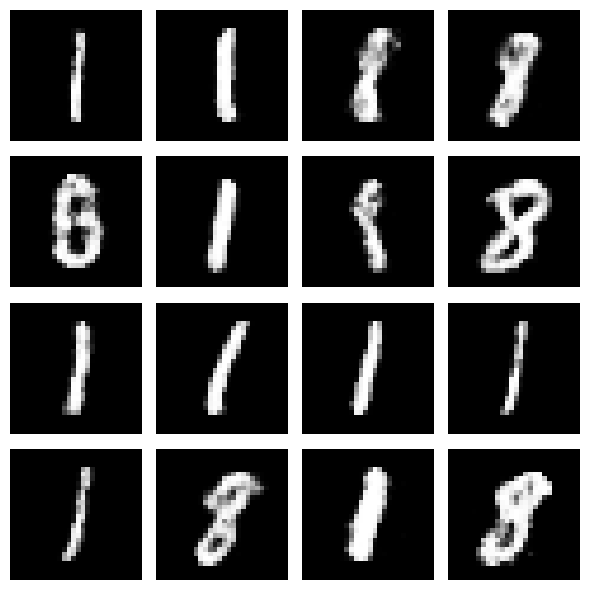

In [8]:
show_generated_images(G, LATENT_DIM, device)

## Comparison with Task 1

Because both tasks evaluate the same mathematical formula, training dynamics are equivalent. Loss curves had the same shape and peaked at the same epochs; generated image quality at 5, 10, and 50 epochs was visually indistinguishable between the two runs. Any differences are attributable to floating-point rounding order, not a change in the loss landscape.